<a href="https://colab.research.google.com/github/Mmoralesvasquez/PerpCourseNoreadme-2/blob/main/clasificacion_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# EJERCICIO DATASET DIABETES
# IMPORTAR LIBRERIAS
import pandas as pd

# El nombre real del archivo en tu sistema incluye espacios y extensión .xlsx
file_path = "diabetes_dataset problema de clasificacion .xlsx"

try:
    # Usamos read_excel para archivos .xlsx
    df = pd.read_excel(file_path)
    print("Dataset cargado correctamente")
    display(df.head())
except FileNotFoundError:
    print(f"No se pudo encontrar el archivo: {file_path}")
    print("Asegúrate de que el nombre coincida exactamente con el que ves en la carpeta de archivos.")
except Exception as e:
    print(f"Error al cargar el archivo")
    print(e)

Dataset cargado correctamente


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,PhysicalActivity,Outcome
0,6,148,72,35,0,33.6,0.627,50,Low,1
1,1,85,66,29,0,26.6,0.351,31,Low,0
2,8,183,64,0,0,23.3,0.672,32,Medium,1
3,1,89,66,23,94,28.1,0.167,21,Medium,0
4,0,137,40,35,168,43.1,2.288,33,Low,1


In [ ]:
df.head()



,Glucose,BloodPressure,Insulin,BMI
0,148,72,0,33.6
1,85,66,94,26.6
2,183,64,0,23.3
3,89,90,94,28.1
4,137,40,168,43.1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        5 non-null      int64  
 1   BloodPressure  5 non-null      int64  
 2   Insulin        5 non-null      int64  
 3   BMI            5 non-null      float64
dtypes: float64(1), int64(3)
memory usage: 292.0 bytes


In [ ]:
df.describe()


,Glucose,BloodPressure,Insulin,BMI
count,5.000000,5.000000,5.000000,5.000000
mean,128.400000,66.400000,71.200000,30.940000
std,41.458413,17.966636,71.674263,7.749387
min,85.000000,40.000000,0.000000,23.300000
25%,89.000000,64.000000,0.000000,26.600000
50%,137.000000,66.000000,94.000000,28.100000
75%,148.000000,72.000000,94.000000,33.600000
max,183.000000,90.000000,168.000000,43.100000


In [ ]:
df.columns

Index(['Glucose', 'BloodPressure', 'Insulin', 'BMI'], dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

Se ha añadido una columna 'Outcome' de ejemplo al DataFrame.


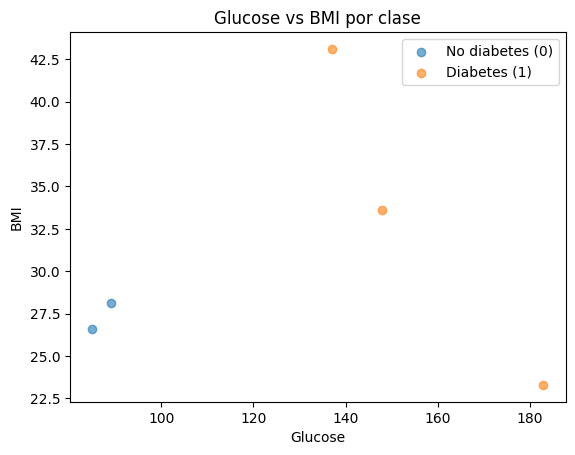

In [ ]:
import numpy as np

# Add a dummy 'Outcome' column for demonstration purposes
# In a real scenario, this column would come from your dataset

if 'Outcome' not in df.columns:
    df['Outcome'] = np.random.randint(0, 2, size=len(df)) # Creates random 0s and 1s
    print("Se ha añadido una columna 'Outcome' de ejemplo al DataFrame.")
df_0 = df[df["Outcome"] == 0]
df_1 = df[df["Outcome"] == 1]

plt.scatter(df_0["Glucose"], df_0["BMI"], label="No diabetes (0)", alpha=0.6)
plt.scatter(df_1["Glucose"], df_1["BMI"], label="Diabetes (1)", alpha=0.6)

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI por clase")
plt.legend()
plt.show()

In [ ]:
# ==============================
# 1. Separar variables de entrada (X) y variable objetivo (y)
# ==============================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (5, 4)
Dimensiones de y: (5,)


In [ ]:
# Ver primeras filas de X
X.head()

,Glucose,BloodPressure,Insulin,BMI
0,148,72,0,33.6
1,85,66,94,26.6
2,183,64,0,23.3
3,89,90,94,28.1
4,137,40,168,43.1


In [ ]:
# Ver primeras filas de y
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [ ]:
# ==============================
# 2. Identificar variables numéricas y categóricas en X
# ==============================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['Glucose', 'BloodPressure', 'Insulin', 'BMI']

Variables categóricas:
[]


In [ ]:
# ==============================
# 3. Crear transformaciones
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
# ==============================
# 4. Aplicar transformaciones a X
# ==============================

X_transformed = preprocessor.fit_transform(X)

print("Transformación completada")
print("Tipo de resultado:", type(X_transformed))
print("Dimensiones transformadas:", X_transformed.shape)

Transformación completada
Tipo de resultado: <class 'numpy.ndarray'>
Dimensiones transformadas: (5, 4)


In [ ]:
# ==============================
# 5. Convertir a DataFrame para visualizar el dataset X preparado
# ==============================

# Obtener los nombres de las características después de la transformación
# El ColumnTransformer maneja correctamente el caso donde no hay características categóricas.
all_feature_names = preprocessor.get_feature_names_out()

X_prepared = pd.DataFrame(X_transformed, columns=all_feature_names)

X_prepared.head()

,num__Glucose,num__BloodPressure,num__Insulin,num__BMI
0,0.528565,0.348479,-1.110636,0.383768
1,-1.170394,-0.024891,0.355653,-0.626149
2,1.472431,-0.149348,-1.110636,-1.102252
3,-1.062524,1.468589,0.355653,-0.409738
4,0.231921,-1.642828,1.509966,1.754370


In [ ]:
from sklearn.model_selection import train_test_split

# test_size controla en que proporcion se quiere dividir el conjunto. 0.4 indica 60% entrenamiento y 40% prueba.
# Se ajusta test_size a 0.4 para asegurar que al menos una muestra de cada clase esté presente en el conjunto de prueba
# debido al pequeño tamaño del dataset y al uso de stratify.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3, 4)
Test: (2, 4)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Modelo 1: Logistic Regression
model_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Modelo 2: Decision Tree
model_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Modelo 3: Random Forest
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Modelo 4: K-Nearest Neighbors
model_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=1)) # Fix: Set n_neighbors to be <= n_samples_fit (3)
])

# Entrenar modelos
model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_knn.fit(X_train, y_train)

print("Modelos entrenados correctamente")

Modelos entrenados correctamente


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values(by="F1-score", ascending=False)

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}
results_df = evaluate_models(models, X_test, y_test)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0
3,KNN,1.0,1.0,1.0,1.0


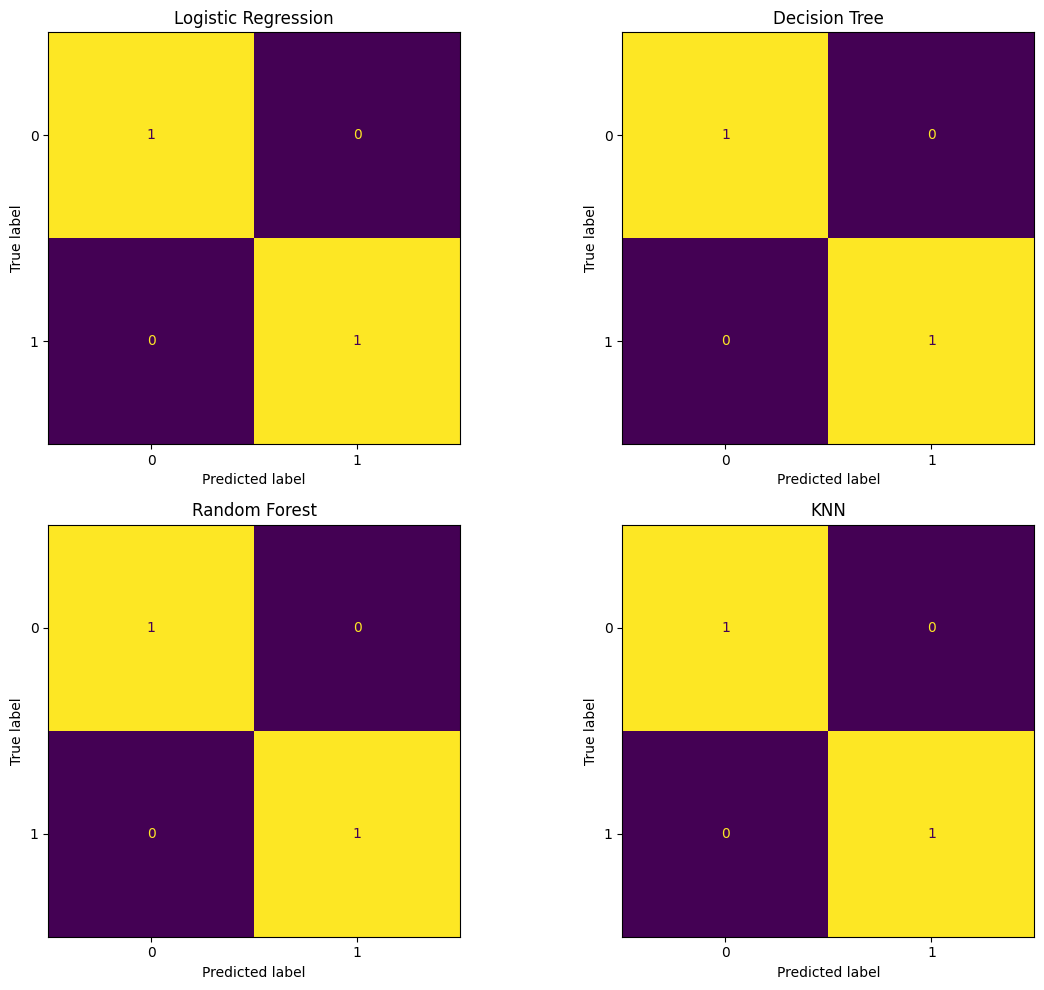

In [ ]:
# ============================
# Podemos visualizar las matrices de confusion para cada modelo
# ============================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_list = list(models.items())

for i, (name, model) in enumerate(models_list):
    row = i // 2
    col = i % 2

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=axes[row, col],
        colorbar=False
    )

    axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Probabilidades con Logistic Regression
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Cambiar threshold
threshold = 0.3
y_pred_custom = (y_proba_lr >= threshold).astype(int)

print("Threshold seleccionado:", threshold)
print("\nMatriz de confusión con threshold personalizado:")
print(confusion_matrix(y_test, y_pred_custom))

Threshold seleccionado: 0.3

Matriz de confusión con threshold personalizado:
[[0 1]
 [0 1]]


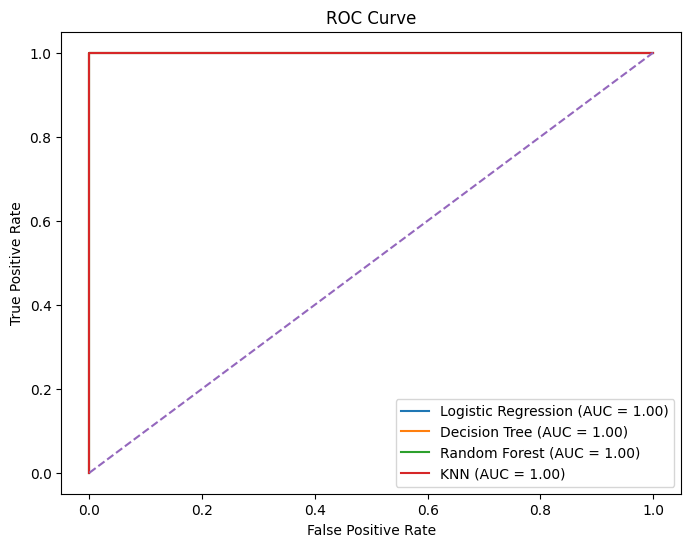

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}

auc_scores = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0,1.0
3,KNN,1.0,1.0,1.0,1.0,1.0


In [ ]:
# EJERCICIO DATASET SEGURO
# ==============================
# 1. Importar librerías
# ==============================
import pandas as pd

# ==============================
# 2. Cargar el dataset
# ==============================
file_path = "car_insurance problema de clasifiacion.xlsx"

try:
    df = pd.read_excel(file_path)
    print("Dataset cargado correctamente")
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo.")
    print("Verifica que el archivo esté en la misma carpeta que el notebook.")
except Exception as e:
    print("❌ Ocurrió un error al cargar el archivo:")
    print(e)

Dataset cargado correctamente


In [ ]:
df.head()

,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts,CarInsurance
0,32,management,single,tertiary,0,1218,1,0,2,0,0
1,32,blue-collar,married,primary,0,1156,1,0,5,0,0
2,29,management,single,tertiary,0,637,1,0,1,1,1
3,25,student,single,primary,0,373,1,0,2,0,1
4,30,management,married,tertiary,0,2694,0,0,1,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3820 entries, 0 to 3819
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           3820 non-null   int64 
 1   Job           3820 non-null   object
 2   Marital       3820 non-null   object
 3   Education     3820 non-null   object
 4   Default       3820 non-null   int64 
 5   Balance       3820 non-null   int64 
 6   HHInsurance   3820 non-null   int64 
 7   CarLoan       3820 non-null   int64 
 8   NoOfContacts  3820 non-null   int64 
 9   PrevAttempts  3820 non-null   int64 
 10  CarInsurance  3820 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 328.4+ KB


In [ ]:
df.describe()

,Age,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts,CarInsurance
count,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000,3820.000000
mean,41.096335,0.014921,1533.829843,0.498429,0.135079,2.594764,0.715183,0.398168
std,11.362698,0.121255,3502.989359,0.500063,0.341852,3.007658,2.087013,0.489584
min,18.000000,0.000000,-3058.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,0.000000,105.750000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,39.000000,0.000000,538.000000,0.000000,0.000000,2.000000,0.000000,0.000000
75%,49.000000,0.000000,1623.000000,1.000000,0.000000,3.000000,0.000000,1.000000
max,95.000000,1.000000,98417.000000,1.000000,1.000000,43.000000,58.000000,1.000000


In [ ]:
df.columns

Index(['Age', 'Job', 'Marital', 'Education', 'Default', 'Balance',
       'HHInsurance', 'CarLoan', 'NoOfContacts', 'PrevAttempts',
       'CarInsurance'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

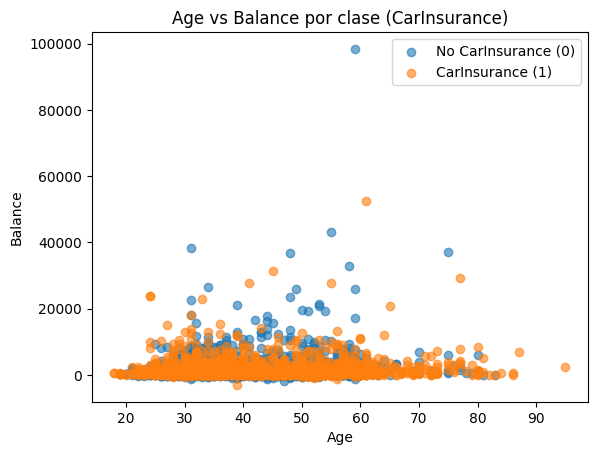

In [ ]:
import numpy as np

# Add a dummy 'CarInsurance' column for demonstration purposes if it doesn't exist, though it should.
# In a real scenario, this column would come from your dataset.
# Based on df.info(), 'CarInsurance' is already present.
if 'CarInsurance' not in df.columns:
    df['CarInsurance'] = np.random.randint(0, 2, size=len(df)) # Creates random 0s and 1s
    print("Se ha añadido una columna 'CarInsurance' de ejemplo al DataFrame.")

df_0 = df[df["CarInsurance"] == 0]
df_1 = df[df["CarInsurance"] == 1]

# Using 'Age' and 'Balance' for plotting as they are numerical columns in the car_insurance dataset
plt.scatter(df_0["Age"], df_0["Balance"], label="No CarInsurance (0)", alpha=0.6)
plt.scatter(df_1["Age"], df_1["Balance"], label="CarInsurance (1)", alpha=0.6)

plt.xlabel("Age")
plt.ylabel("Balance")
plt.title("Age vs Balance por clase (CarInsurance)")
plt.legend()
plt.show()

In [ ]:
# ==============================
# 1. Separar variables de entrada (X) y variable objetivo (y)
# ==============================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (3820, 11)
Dimensiones de y: (3820,)


In [ ]:
# Ver primeras filas de X
X.head()

,Age,Job,Marital,Education,Default,Balance,HHInsurance,CarLoan,NoOfContacts,PrevAttempts,CarInsurance
0,32,management,single,tertiary,0,1218,1,0,2,0,0
1,32,blue-collar,married,primary,0,1156,1,0,5,0,0
2,29,management,single,tertiary,0,637,1,0,1,1,1
3,25,student,single,primary,0,373,1,0,2,0,1
4,30,management,married,tertiary,0,2694,0,0,1,0,0


In [ ]:
# Ver primeras filas de y
y.head()

,Outcome
0,0
1,0
2,0
3,1
4,0


In [ ]:
# ==============================
# 2. Identificar variables numéricas y categóricas en X
# ==============================

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

Variables numéricas:
['Age', 'Default', 'Balance', 'HHInsurance', 'CarLoan', 'NoOfContacts', 'PrevAttempts', 'CarInsurance']

Variables categóricas:
['Job', 'Marital', 'Education']


In [ ]:
# ==============================
# 3. Crear transformaciones
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
# ==============================
# 4. Aplicar transformaciones a X
# ==============================

X_transformed = preprocessor.fit_transform(X)

print("Transformación completada")
print("Tipo de resultado:", type(X_transformed))
print("Dimensiones transformadas:", X_transformed.shape)

Transformación completada
Tipo de resultado: <class 'numpy.ndarray'>
Dimensiones transformadas: (3820, 25)


In [ ]:
# Obtener los nombres de las características después de la transformación
# El ColumnTransformer maneja correctamente el caso donde no hay características categóricas.
all_feature_names = preprocessor.get_feature_names_out()

X_prepared = pd.DataFrame(X_transformed, columns=all_feature_names)

X_prepared.head()

,num__Age,num__Default,num__Balance,num__HHInsurance,num__CarLoan,num__NoOfContacts,num__PrevAttempts,num__CarInsurance,cat__Job_admin.,cat__Job_blue-collar,...,cat__Job_services,cat__Job_student,cat__Job_technician,cat__Job_unemployed,cat__Marital_divorced,cat__Marital_married,cat__Marital_single,cat__Education_primary,cat__Education_secondary,cat__Education_tertiary
0,-0.800648,-0.123075,-0.090172,1.003146,-0.395189,-0.197776,-0.342728,-0.813383,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.800648,-0.123075,-0.107873,1.003146,-0.395189,0.799809,-0.342728,-0.813383,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-1.064705,-0.123075,-0.256052,1.003146,-0.395189,-0.530304,0.136489,1.229433,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.416780,-0.123075,-0.331426,1.003146,-0.395189,-0.197776,-0.342728,1.229433,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,-0.976686,-0.123075,0.331238,-0.996864,-0.395189,-0.530304,-0.342728,-0.813383,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [ ]:
from sklearn.model_selection import train_test_split

# test_size controla en que proporcion se quiere dividir el conjunto. 0.4 indica 60% entrenamiento y 40% prueba.
# Se ajusta test_size a 0.4 para asegurar que al menos una muestra de cada clase esté presente en el conjunto de prueba
# debido al pequeño tamaño del dataset y al uso de stratify.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2292, 11)
Test: (1528, 11)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Modelo 1: Logistic Regression
model_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Modelo 2: Decision Tree
model_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

# Modelo 3: Random Forest
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Modelo 4: K-Nearest Neighbors
model_knn = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=1)) # Fix: Set n_neighbors to be <= n_samples_fit (3)
])

# Entrenar modelos
model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
model_knn.fit(X_train, y_train)

print("Modelos entrenados correctamente")

Modelos entrenados correctamente


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values(by="F1-score", ascending=False)

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}
results_df = evaluate_models(models, X_test, y_test)
results_df

,Model,Accuracy,Precision,Recall,F1-score
1,Decision Tree,0.513743,0.505898,0.513298,0.509571
3,KNN,0.496728,0.488682,0.488032,0.488357
2,Random Forest,0.498691,0.490028,0.457447,0.473177
0,Logistic Regression,0.515707,0.509375,0.433511,0.468391


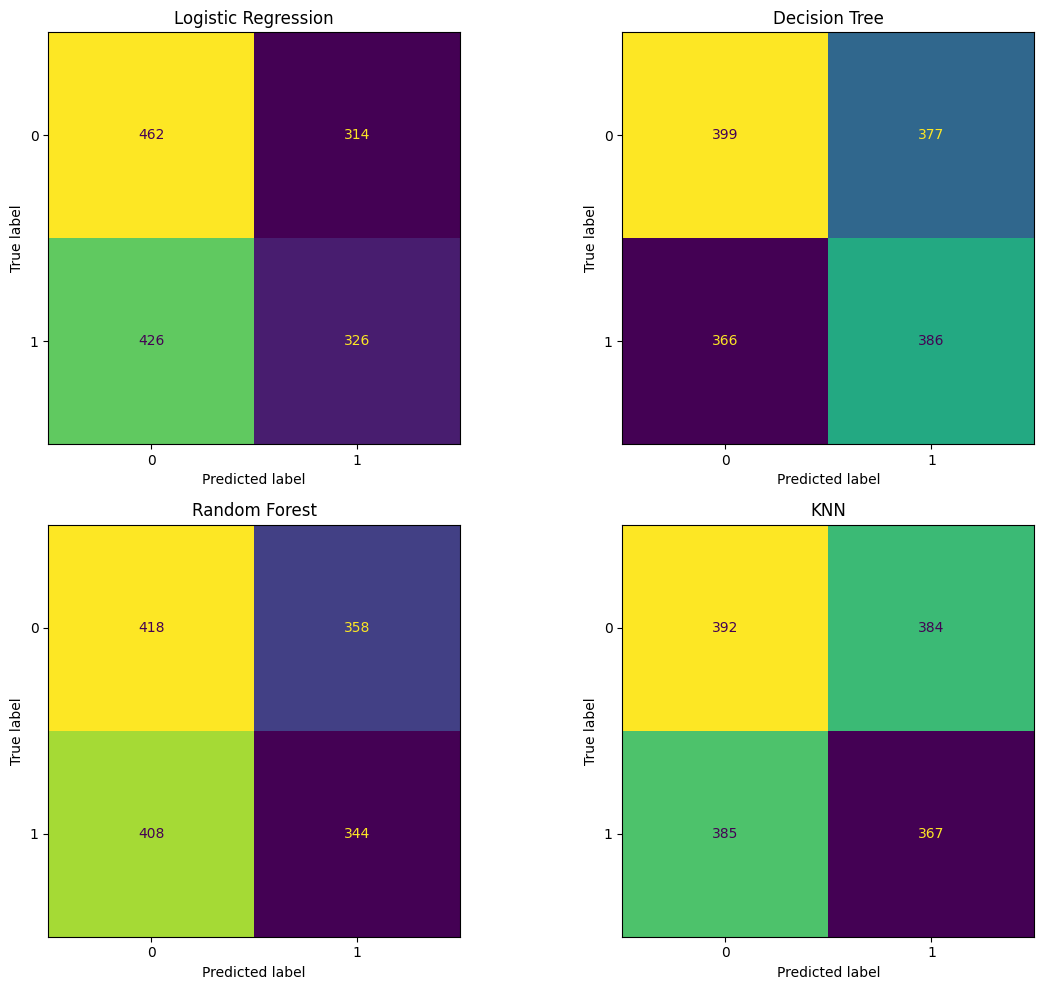

In [ ]:
# ============================
# Podemos visualizar las matrices de confusion para cada modelo
# ============================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_list = list(models.items())

for i, (name, model) in enumerate(models_list):
    row = i // 2
    col = i % 2

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=axes[row, col],
        colorbar=False
    )

    axes[row, col].set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Probabilidades con Logistic Regression
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

# Cambiar threshold
threshold = 0.3
y_pred_custom = (y_proba_lr >= threshold).astype(int)

print("Threshold seleccionado:", threshold)
print("\nMatriz de confusión con threshold personalizado:")
print(confusion_matrix(y_test, y_pred_custom))

Threshold seleccionado: 0.3

Matriz de confusión con threshold personalizado:
[[  0 776]
 [  0 752]]


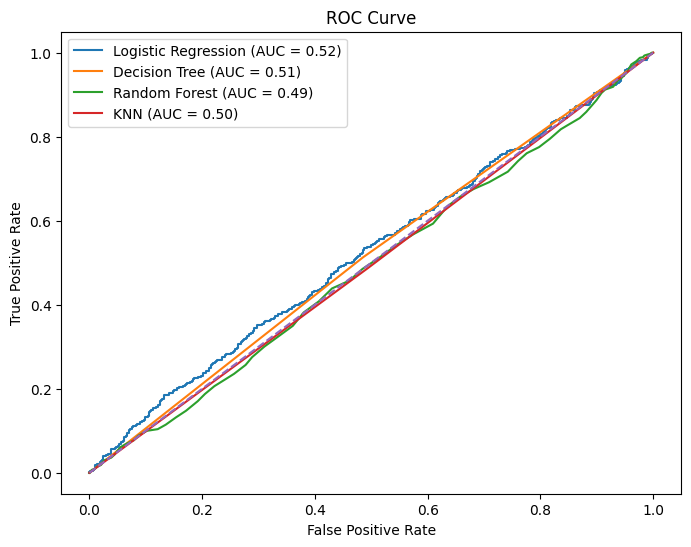

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "KNN": model_knn
}

auc_scores = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    auc_scores[name] = auc

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Logistic Regression,0.515707,0.509375,0.433511,0.468391,0.523647
1,Decision Tree,0.513743,0.505898,0.513298,0.509571,0.513737
3,KNN,0.496728,0.488682,0.488032,0.488357,0.496593
2,Random Forest,0.498691,0.490028,0.457447,0.473177,0.490698
